# **🔋EV Battery Failure Prediction**

> ## **Machine Learning Classification Project**

This notebook builds a Machine Learning model to predict whether an
Electric Vehicle (EV) battery is likely to experience a failure.

### **What this notebook covers:**
- Load and understand the dataset
- Perform basic data exploration
- Check missing values
- Analyze the target variable
- Prepare the data
- Handle categorical features
- Split data into training and testing sets
- Train a CatBoost classification model
- Evaluate the model using Accuracy, F1-score and ROC-AUC
- Analyze important features
- Make predictions
- Summarize the results

In [1]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# CatBoost
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")

## **1. Load the Dataset**

First, we load the EV battery dataset and look at its size and
first few rows.

In [2]:
# Load dataset
df = pd.read_csv("/kaggle/input/datasets/sarveshchhetri/ev-battery-failure-prediction-dataset-200k/ev_battery_failure_dataset.csv")

# Display dataset shape
print("Dataset Shape:", df.shape)

# Display first 5 rows
df.head()

Dataset Shape: (200000, 70)


,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
0,EV100000,Nissan,Leaf,SUV,2019.0,CATL,LMO,82.54,RWD,98163.0,...,2.0,3.0,0.0,0.0,53.5,66.0,65.2,0.0,401.0,0
1,EV100001,Audi,e-tron,Sedan,2018.0,Samsung SDI,NaN,64.17,AWD,113600.0,...,0.0,3.0,0.0,51.0,38.8,67.8,46.3,40.9,1094.0,0
2,EV100002,Toyota,bZ4X,Van,2018.0,Guoxuan,NMC,90.92,RWD,242253.0,...,4.0,1.0,0.0,36.2,66.1,48.6,0.0,6.5,645.0,0
3,EV100003,Volkswagen,ID.3,Hatchback,2022.0,CATL,NMC,47.35,AWD,83700.0,...,0.0,3.0,1.0,23.4,32.5,58.2,NaN,NaN,867.0,0
4,EV100004,Tesla,Model X,Crossover,2015.0,BYD Battery,NMC,68.04,FWD,88784.0,...,3.0,2.0,1.0,51.2,45.4,51.0,NaN,100.0,1090.0,0


## **2. Understand the Dataset**

Let's check:
- Number of rows and columns
- Data types
- Missing values
- Basic statistics

In [3]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 70 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   vehicle_id                       200000 non-null  object 
 1   vehicle_brand                    193564 non-null  object 
 2   vehicle_model                    191796 non-null  object 
 3   vehicle_type                     193568 non-null  object 
 4   manufacturing_year               190171 non-null  float64
 5   battery_manufacturer             193812 non-null  object 
 6   battery_chemistry                192786 non-null  object 
 7   battery_capacity_kwh             193097 non-null  float64
 8   drive_type                       192732 non-null  object 
 9   odometer_km                      191334 non-null  float64
 10  vehicle_age_years                192317 non-null  float64
 11  fleet_or_private                 191050 non-null  object 
 12  ba

In [4]:
# Statistical summary
df.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
vehicle_id,200000,200000,EV299983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_brand,193564,20,Tesla,21840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_model,191796,55,Model X,5527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_type,193568,6,SUV,58202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
manufacturing_year,190171.0,NaN,NaN,NaN,2019.501333,2.873497,2015.0,2017.0,2020.0,2022.0,2024.0
battery_manufacturer,193812,9,CATL,42675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
battery_chemistry,192786,5,NMC,112993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
battery_capacity_kwh,193097.0,NaN,NaN,NaN,76.236405,21.30233,25.0,60.98,75.35,89.99,149.01
drive_type,192732,3,FWD,86890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
odometer_km,191334.0,NaN,NaN,NaN,102822.193327,87965.819977,500.0,36128.0,78919.0,146010.75,450000.0


In [5]:
# Check missing values
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(
    ascending=False
)

missing_values.head(15)

fast_charge_ratio         9879
average_speed             9849
manufacturing_year        9829
home_charging_ratio       9805
sensor_fault_count        9674
charging_interruptions    9648
state_of_charge           9636
state_of_health           9565
capacity_loss_percent     9559
slow_charge_ratio         9483
cell_temperature_max      9450
cooling_system_health     9408
cell_voltage_avg          9398
charge_efficiency         9305
hard_braking_score        9239
dtype: int64

## **3. Target Variable**

Our target variable is `battery_failure`.

- 0 = Battery failure not detected
- 1 = Battery failure detected

The dataset is imbalanced because there are more normal batteries
than failed batteries.

Therefore, we will use metrics such as F1-score and ROC-AUC along
with accuracy.

battery_failure
0    180079
1     19921
Name: count, dtype: int64


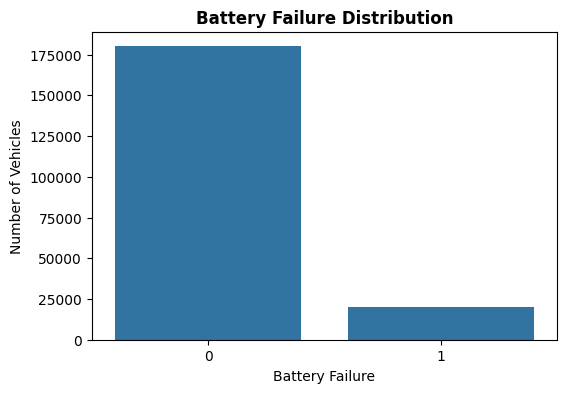

In [18]:
# Count target classes
print(df["battery_failure"].value_counts())

# Plot target distribution
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="battery_failure")

plt.title("Battery Failure Distribution",fontweight='bold')
plt.xlabel("Battery Failure")
plt.ylabel("Number of Vehicles")
plt.show()

## **4. Data Preparation**

We will remove:

- `vehicle_id` because it is only an identifier.
- `predicted_remaining_life_cycles` because it is a prediction-like
  feature and may introduce data leakage if it was calculated using
  information related to the target.

CatBoost can directly handle categorical variables, so we do not need
to manually perform one-hot encoding.

In [7]:
# Separate features and target
X = df.drop(
    columns=[
        "battery_failure",
        "vehicle_id",
        "predicted_remaining_life_cycles"
    ]
)

y = df["battery_failure"]

# Find categorical columns
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Number of features:", X.shape[1])
print("Categorical columns:", categorical_columns)

Number of features: 67
Categorical columns: ['vehicle_brand', 'vehicle_model', 'vehicle_type', 'battery_manufacturer', 'battery_chemistry', 'drive_type', 'fleet_or_private', 'battery_serial', 'terrain_type']


In [8]:
# CatBoost can handle numerical missing values.
# For categorical columns, replace missing values with "Unknown".

X[categorical_columns] = X[categorical_columns].fillna("Unknown")

print("Data preparation completed.")

Data preparation completed.


## **5. Train-Test Split**

We split the dataset into:

- 80% training data
- 20% testing data

`stratify=y` keeps approximately the same percentage of failure and
non-failure cases in both datasets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160000
Testing samples: 40000


## **6. Build the Machine Learning Model**

We will use **CatBoost Classifier**.

CatBoost is useful for this dataset because it can work directly with
categorical variables and can handle missing numerical values.

We also use class balancing because battery failures are less common
than normal battery cases.

In [10]:
# Create CatBoost model
model = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.08,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    l2_leaf_reg=5,
    verbose=False
)

# Train the model
model.fit(
    X_train,
    y_train,
    cat_features=categorical_columns,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    verbose=False
)

print("Model training completed!")

Model training completed!


## **7. Make Predictions**

The trained model can now predict whether a battery belongs to the
failure or non-failure class.

In [11]:
# Class predictions
y_pred = model.predict(X_test).astype(int).ravel()

# Probability of battery failure
y_probability = model.predict_proba(X_test)[:, 1]

print("Predictions completed.")

Predictions completed.


## **8. Model Evaluation**

We use three important metrics:

### **Accuracy**
Percentage of predictions that are correct.

### **F1-score**
Useful for imbalanced classification because it considers both
precision and recall.

### **ROC-AUC**
Measures how well the model separates failure and non-failure cases.
A value closer to 1 is better.

In [12]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("Model Performance")
print("-" * 30)
print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Model Performance
------------------------------
Accuracy : 0.9485
F1 Score : 0.7859
ROC-AUC  : 0.9893


## **9. Classification Report**

The classification report gives us:

- Precision
- Recall
- F1-score
- Support

Recall is particularly important here because missing an actual
battery failure can be more serious than incorrectly flagging a
healthy battery.

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     36016
           1       0.67      0.95      0.79      3984

    accuracy                           0.95     40000
   macro avg       0.83      0.95      0.88     40000
weighted avg       0.96      0.95      0.95     40000



## **10. Confusion Matrix**

The confusion matrix helps us understand how many predictions were:

- True Negative
- False Positive
- False Negative
- True Positive

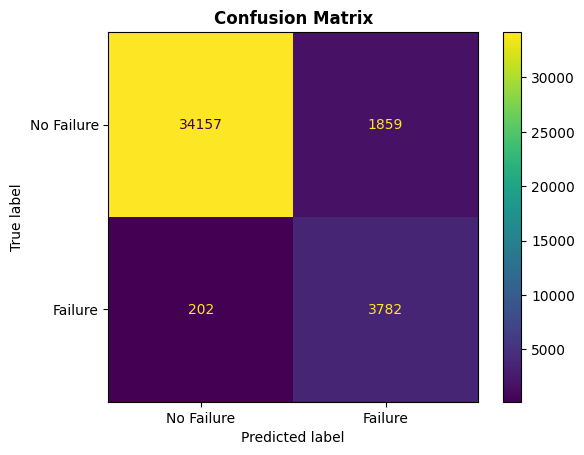

In [19]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
)

disp.plot()
plt.title("Confusion Matrix",fontweight='bold')
plt.show()

## **11. Feature Importance**

Feature importance tells us which variables contributed most to the
model's predictions.

This helps us understand which battery characteristics may be useful
for predicting battery failure.

In [15]:
# Get feature importance
importance = pd.Series(
    model.get_feature_importance(),
    index=X.columns
).sort_values(ascending=False)

# Display top 15 features
print(importance.head(15))

charging_quality_score    10.818113
BMS_warning_count          8.480099
battery_stress_index       6.864136
maintenance_score          6.368588
cooling_system_health      5.857999
battery_health_percent     4.986796
thermal_health_score       4.673408
manufacturing_year         3.274726
thermal_runaway_risk       3.079248
capacity_loss_percent      2.791111
vehicle_age_years          2.662401
voltage_imbalance          2.622340
state_of_health            2.580360
charging_interruptions     2.523713
cell_voltage_std           2.474892
dtype: float64


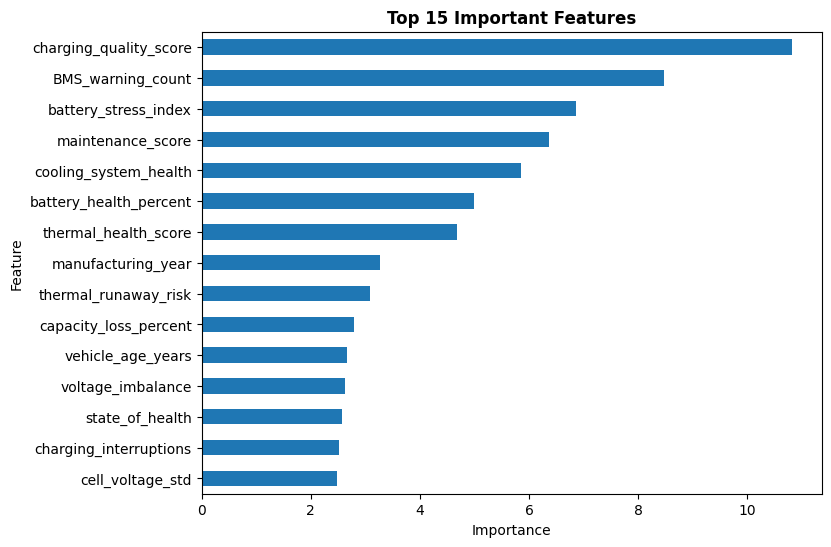

In [20]:
# Plot top 15 important features
plt.figure(figsize=(8, 6))

importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Important Features",fontweight='bold')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## **12. Example Prediction**

Let's use the trained model to generate battery failure probabilities.

A higher probability means the model considers the vehicle more
likely to experience battery failure.

In [17]:
# Create prediction results
results = X_test.copy()

results["Actual_Failure"] = y_test.values
results["Predicted_Failure"] = y_pred
results["Failure_Probability"] = y_probability

results.head(10)

,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,vehicle_age_years,...,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,Actual_Failure,Predicted_Failure,Failure_Probability
179921,GM,Silverado EV,Hatchback,2024.0,Samsung SDI,LFP,57.17,FWD,29241.0,2.14,...,0.0,0.0,0.0,0.0,85.5,72.0,0.0,0,0,2.004064e-08
69410,Ford,Unknown,Hatchback,2020.0,LG Energy Solution,NMC,51.40,AWD,93642.0,6.26,...,NaN,0.0,15.6,32.8,61.7,66.0,0.0,0,0,1.104063e-05
31083,BYD,Tang,SUV,2015.0,Envision AESC,Unknown,88.35,FWD,11194.0,11.04,...,3.0,1.0,44.7,28.0,62.1,57.6,71.4,0,0,3.678626e-04
175661,Unknown,Model X,SUV,2022.0,LG Energy Solution,NCA,98.41,RWD,44128.0,NaN,...,2.0,0.0,17.8,0.0,56.5,81.8,3.1,0,0,6.440125e-06
36449,Toyota,bZ4X,Sedan,2020.0,LG Energy Solution,NMC,70.67,Unknown,76257.0,6.05,...,0.0,0.0,47.4,18.3,61.1,54.5,44.5,0,0,4.540966e-06
118768,GM,Silverado EV,Hatchback,2022.0,BYD Battery,NMC,NaN,AWD,9157.0,3.71,...,1.0,0.0,26.8,0.0,65.5,96.0,37.6,0,0,7.979833e-08
73312,Tesla,Model X,Van,2019.0,LG Energy Solution,NMC,92.58,Unknown,57737.0,7.16,...,8.0,0.0,42.1,31.6,50.1,63.6,35.8,1,0,3.671491e-01
148061,Tesla,Model 3,SUV,2017.0,LG Energy Solution,NCA,98.57,AWD,194093.0,9.04,...,4.0,NaN,38.1,70.9,NaN,36.9,13.9,0,0,4.175087e-01
67407,Audi,e-tron GT,Sedan,2017.0,Northvolt,NMC,62.96,FWD,NaN,9.17,...,1.0,0.0,1.5,46.1,67.6,59.3,0.0,0,0,2.496497e-04
10795,GM,Chevrolet Bolt,Sedan,2021.0,Samsung SDI,NMC,56.60,RWD,57915.0,4.94,...,0.0,1.0,0.0,14.9,57.2,85.4,10.8,0,0,1.493957e-06


## **13. Final Model Results**

The CatBoost model achieved approximately:

- **Accuracy: 94.85%**
- **F1-score: 78.59%**
- **ROC-AUC: 98.93%**

The high ROC-AUC indicates that the model is very effective at
distinguishing between batteries with and without failure risk.

The F1-score is also important because the dataset is imbalanced.

# **Conclusion**

In this project, we developed a Machine Learning model to predict
Electric Vehicle battery failure.

The dataset contained 200,000 records and 70 columns. After exploring
the data, we handled missing categorical values, removed the vehicle
identifier and excluded the predicted remaining-life feature to reduce
the risk of data leakage.

A CatBoost Classifier was selected because it can handle categorical
features effectively and works well for classification problems.

The final model achieved approximately **94.85% accuracy** and a
**98.93% ROC-AUC score**, showing strong predictive performance.

The model can help identify vehicles that may have a higher risk of
battery failure. Feature importance analysis also provides useful
information about the battery and vehicle characteristics that
influence the predictions.

### **Key Takeaways**

- EV battery failure can be predicted using Machine Learning.
- CatBoost performs well with mixed numerical and categorical data.
- Accuracy alone is not enough for an imbalanced dataset.
- F1-score and ROC-AUC provide additional information about model
  performance.
- Feature importance can help understand the major factors related
  to battery failure.

Overall, the developed model provides a strong baseline for an
EV battery predictive-maintenance system.